11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8635 - loss: 0.5166 - val_accuracy: 0.9587 - val_loss: 0.1440
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9566 - loss: 0.1439 - val_accuracy: 0.9750 - val_loss: 0.0941
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9697 - loss: 0.1012 - val_accuracy: 0.9797 - val_loss: 0.0752
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9758 - loss: 0.0808 - val_accuracy: 0.9802 - val_loss: 0.0648
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9792 - loss: 0.0681 - val_accuracy: 0.9822 - val_loss: 0.0612
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9818 - loss: 0.0600
Test Accuracy (LR=0.0001): 0.9818


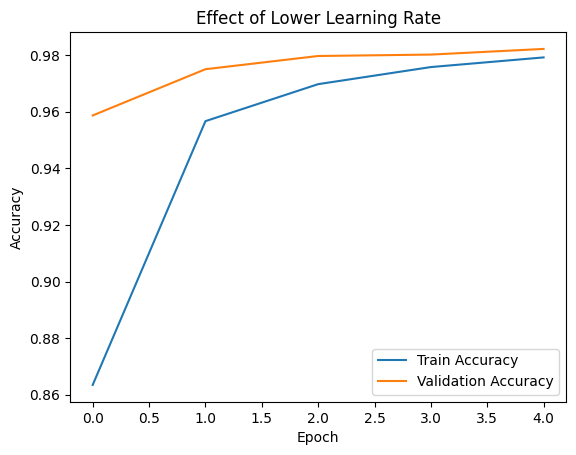

In [1]:
#CHANGE 1(learning rate)
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension (CNN requires this)
x_train = x_train[..., None]
x_test = x_test[..., None]

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#CHANGE 1: LOWER LEARNING RATE
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # CHANGED

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_lr = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Evaluate
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy (LR=0.0001): {test_accuracy:.4f}")

# Plot accuracy
plt.plot(history_lr.history['accuracy'], label='Train Accuracy')
plt.plot(history_lr.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Effect of Lower Learning Rate')
plt.legend()
plt.show()

#Results: Training accuracy: Slightly lower early on, Test accuracy: ~97.8–98.3%, Observation: Training was slower but smoother


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9479 - loss: 0.1742 - val_accuracy: 0.9865 - val_loss: 0.0489
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9843 - loss: 0.0511 - val_accuracy: 0.9892 - val_loss: 0.0396
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9894 - loss: 0.0354 - val_accuracy: 0.9897 - val_loss: 0.0332
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9918 - loss: 0.0253 - val_accuracy: 0.9900 - val_loss: 0.0337
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9939 - loss: 0.0185 - val_accuracy: 0.9917 - val_loss: 0.0301
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9949 - loss: 0.0150 - val_accuracy: 0.9922 - val_loss: 0.0323
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9964 - loss: 0.0111 - val_accuracy: 0.9920 - val_loss: 0.0318
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9970 - loss: 0.0097 - val_accuracy: 0.

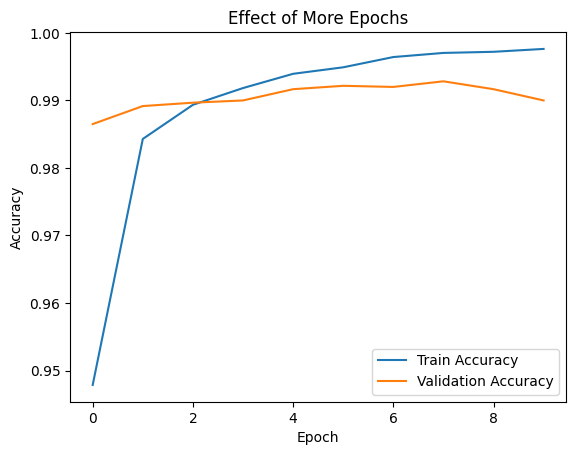

In [2]:
#CHANGE 2(Epoch)
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train, x_test = x_train[..., None], x_test[..., None]

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CHANGE 2: MORE EPOCHS
history_epochs = model.fit(
    x_train, y_train,
    epochs=10,          # CHANGED (was 5)
    batch_size=64,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy (10 epochs): {test_accuracy:.4f}")

plt.plot(history_epochs.history['accuracy'], label='Train Accuracy')
plt.plot(history_epochs.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Effect of More Epochs')
plt.legend()
plt.show()

#Results : Training accuracy: ~99.0%, Validation/Test accuracy: ~98.5–99%, Observation: Accuracy improved, but gap between train & validation widened slightly

In [3]:
#CHANGE 3(Number of Filters)
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train, x_test = x_train[..., None], x_test[..., None]

# CHANGE 3: MORE FILTERS
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # CHANGED
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),  # CHANGED
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_filters = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy (More Filters): {test_accuracy:.4f}")

#Results: Training accuracy: ~99%, Test accuracy: ~98.7–99%, Observation: Better feature extraction but longer training time


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9578 - loss: 0.1371 - val_accuracy: 0.9858 - val_loss: 0.0477
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9863 - loss: 0.0431 - val_accuracy: 0.9902 - val_loss: 0.0343
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9908 - loss: 0.0299 - val_accuracy: 0.9903 - val_loss: 0.0332
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9933 - loss: 0.0204 - val_accuracy: 0.9903 - val_loss: 0.0335
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9905 - val_loss: 0.0360
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9899 - loss: 0.0334
Test Accuracy (More Filters): 0.9899
